# Example Notebook for the Toy Experiment in Figure 2

In [1]:
#@title Import
import os

import jax
jax.config.update("jax_enable_x64", True)

from jax import numpy as jnp
from jax import random as jr
from jax import vmap, lax

from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

import numpy as np

from src.lds.models import LinearGaussianSSM, LinearGaussianConjugateSSM
from src.lds.inference import lgssm_filter, lgssm_smoother
from src.lds.inference import ParamsLGSSM, ParamsLGSSMInitial, ParamsLGSSMDynamics, ParamsLGSSMEmissions
from src.lds.inference import PosteriorGSSMFiltered, PosteriorGSSMSmoothed
from src.lds.inference import make_lgssm_params
from src.parameters import ParameterProperties, ParameterSet
from src.utils.utils import random_rotation, rotate_subspace
from src.smds.models import StiefelManifoldSSM
from src.smds.models import ParamsSMDS, ParamsSMDSEmissions
from tensorflow_probability.substrates.jax.distributions import MultivariateNormalFullCovariance as MVN
from tensorflow_probability.substrates.jax.distributions import InverseGamma as IG

from sklearn.metrics import mean_squared_error as mse
from sklearn.metrics import r2_score, explained_variance_score
from sklearn.decomposition import PCA

from tqdm import tqdm

import time

In [2]:
def subspace_angles(A, B):
    """
    Compute the angle between two subspaces
    https://docs.scipy.org/doc/scipy/reference/generated/scipy.linalg.subspace_angles.html
    """

    # 1. Compute orthonormal bases of column spaces
    QA = jnp.linalg.svd(A, full_matrices=False)[0]
    QB = jnp.linalg.svd(B, full_matrices=False)[0]

    # 2. Compute SVD for cosine
    QA_H_QB = jnp.dot(QA.T.conj(), QB)
    sigma = jnp.linalg.svd(QA_H_QB, full_matrices=False, compute_uv=False)

    # 3. Compute matrix B
    B = QB - jnp.dot(QA, QA_H_QB)

    # 4. Compute SVD for sine
    mask = sigma ** 2 >= 0.5
    mu_arcsin = jnp.arcsin(jnp.clip(jnp.linalg.svd(B, full_matrices=False, compute_uv=False), a_min=-1., a_max=1.))

    # 5. Compute the principal angles
    theta = jnp.where(mask, mu_arcsin, jnp.arccos(jnp.clip(sigma[::-1], a_min=-1., a_max=1.)))

    return theta

def compute_subspace_angle_matrix(weights):
    # weights: T x N x D
    # output: T x T

    T = weights.shape[0]

    def _compute_subspace_angles(carry, anchor):
        sa = vmap(subspace_angles, in_axes=(0, None))(weights, weights[anchor])
        return None, sa

    _, subspace_angle_matrix = lax.scan(_compute_subspace_angles, init=None, xs=jnp.arange(T))

    return subspace_angle_matrix

def compute_rotation(observations, emissions):
    """
    Given:
      observations: jnp.ndarray of shape (num_trials, num_timesteps, emission_dim)
      emissions:    jnp.ndarray of shape (num_trials, emission_dim, latent_dim)
    Returns:
      R: jnp.ndarray of shape (latent_dim, latent_dim)
         A rotation matrix such that rotating each trial's emission matrix (i.e. computing O_i @ R)
         orders the latent columns in descending order of explained variance.
      explained_variances: jnp.ndarray of shape (latent_dim,)
         Variances explained by the rotated latent dimensions.
    """
    # Compute latent factors per trial: shape (num_trials, num_timesteps, latent_dim)
    # Using the fact that the emission matrices are orthogonal.
    latent_factors = jnp.einsum('...te,...el->...tl', observations, emissions)
    
    # Stack trials and timesteps together, so we have all latent factors in one 2D array.
    if latent_factors.ndim == 3:
        num_trials, num_timesteps, latent_dim = latent_factors.shape
    else:
        num_timesteps, latent_dim = latent_factors.shape
        num_trials = 1

    latent_factors_stacked = latent_factors.reshape(num_trials * num_timesteps, latent_dim)
    
    # Perform SVD on the aggregated latent factors.
    # latent_factors_stacked = U @ diag(S) @ Vt, with singular values S in descending order.
    U, S, Vt = jnp.linalg.svd(latent_factors_stacked, full_matrices=False)
    
    # The rotation matrix that aligns with the principal directions is given by V = Vt.T.
    # Rotating the latent factors as L_rot = latent_factors_stacked @ V will yield columns
    # with decreasing variance (S^2 are proportional to the variances).
    R = Vt.T
    
    # Compute the explained variances for each rotated latent dimension.
    explained_variances = (S ** 2) / (latent_factors_stacked.shape[0] - 1)
    
    return R, explained_variances

def explained_variance(observations, emissions):
    """
    Given:
      observations: jnp.ndarray of shape (num_trials, num_timesteps, emission_dim)
      emissions:    jnp.ndarray of shape (num_trials, emission_dim, latent_dim)
    Returns:
      R: jnp.ndarray of shape (latent_dim, latent_dim)
         A rotation matrix such that rotating each trial's emission matrix (i.e. computing O_i @ R)
         orders the latent columns in descending order of explained variance.
      explained_variances: jnp.ndarray of shape (latent_dim,)
         Variances explained by the rotated latent dimensions.
    """
    # Compute latent factors per trial: shape (num_trials, num_timesteps, latent_dim)
    # Using the fact that the emission matrices are orthogonal.
    latent_factors = jnp.einsum('...te,...el->...tl', observations, emissions)
    
    # Stack trials and timesteps together, so we have all latent factors in one 2D array.
    if latent_factors.ndim == 3:
        num_trials, num_timesteps, latent_dim = latent_factors.shape
    else:
        num_timesteps, latent_dim = latent_factors.shape
        num_trials = 1
    latent_factors_stacked = latent_factors.reshape(num_trials * num_timesteps, latent_dim)
    
    # Perform SVD on the aggregated latent factors.
    # latent_factors_stacked = U @ diag(S) @ Vt, with singular values S in descending order.
    U, S, Vt = jnp.linalg.svd(latent_factors_stacked, full_matrices=False)
    
    # Compute the explained variances for each rotated latent dimension.
    explained_variances = (S ** 2) / (latent_factors_stacked.shape[0] - 1)
    
    return explained_variances

def compute_explained_variance(y, full_H, H):
    ev = explained_variance(y, H)
    total_ev = explained_variance(y, full_H).sum()
    return ev / total_ev

def compute_cos_dist(a, b):
    def _l2(x):
        return jnp.sqrt(jnp.sum(jnp.square(x)))
    return 1 - (a @ b) / (_l2(a) * _l2(b))

def compute_cos_sim(a, b):
    def _l2(x):
        return jnp.sqrt(jnp.sum(jnp.square(x)))
    return (a @ b) / (_l2(a) * _l2(b))

def moving_average_adaptive(x, window_size):
    kernel = jnp.ones(window_size)

    # Numerator: regular convolution
    smoothed = jnp.convolve(x, kernel, mode='same')

    # Denominator: convolution with ones to count valid entries
    counts = jnp.convolve(jnp.ones_like(x), kernel, mode='same')

    return smoothed / counts

# Define True SMDS Model and Simulate Data

In [3]:
D = true_state_dim = 2
N = emission_dim = 10
num_trials = 750
num_conditions = 4
num_timesteps = 30

smoothing_window = 100

dof = true_state_dim * (emission_dim - true_state_dim)
dof_shape = (true_state_dim, emission_dim - true_state_dim)

true_model = StiefelManifoldSSM(state_dim=true_state_dim, 
                                emission_dim=emission_dim,
                                num_trials=num_trials,
                                num_conditions=num_conditions)

key = jr.PRNGKey(313456)

dynamics = random_rotation(seed=key, n=true_state_dim, theta=jnp.pi/5)

key, key_root = jr.split(key)
true_U_base = jnp.eye(emission_dim)

key, key_root = jr.split(key)
true_tau = jr.uniform(key_root, shape=(dof,), minval=1e-10, maxval=1e-4)

_velocity_cov = jnp.diag(true_tau)
def _get_velocity(prev_velocity, current_key):
    current_velocity_dist = MVN(loc=prev_velocity, covariance_matrix=_velocity_cov)
    current_velocity = current_velocity_dist.sample(seed=current_key)
    return current_velocity, current_velocity

keys = jr.split(key, num_trials)
key = keys[-1]
key, key_root = jr.split(key)
_initial_velocity = jnp.zeros(dof)
_, _velocity = jax.lax.scan(_get_velocity, _initial_velocity, keys[:-1])
_velocity = jnp.concatenate([_initial_velocity[None], _velocity])
_velocity = vmap(moving_average_adaptive, in_axes=(-1, None))(_velocity, smoothing_window).T
true_tau = jnp.var(jnp.diff(_velocity, axis=0), axis=0)
_velocity = _velocity.reshape((num_trials,) + dof_shape)

key, key_root = jr.split(key)
true_params, param_props, true_velocity = true_model.initialize(tau=true_tau,
                                                                U_base=true_U_base,
                                                                key=key, 
                                                                initial_mean=jnp.sqrt(emission_dim/true_state_dim)*jr.normal(key_root, shape=(num_conditions, true_state_dim)),
                                                                dynamics_weights=dynamics,
                                                                dynamics_covariance=jnp.eye(true_state_dim)*1e-2,
                                                                emission_covariance=jnp.eye(emission_dim)*1e-2,
                                                                velocity=_velocity,
                                                                )

conditions = jnp.tile(jnp.arange(num_conditions), num_trials)[:num_trials]
key, key_root = jr.split(key)
true_states, emissions = true_model.sample(true_params, key, num_timesteps, conditions=conditions)

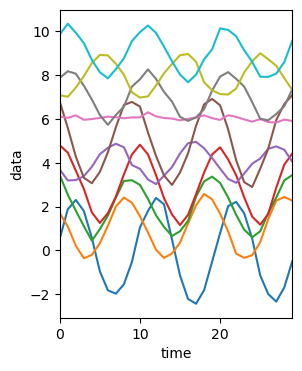

In [4]:
# Plot the true states and emissions
fig, ax = plt.subplots(figsize=(3, 4))
ax.plot(emissions[-1, :, :min(10, N)] + 1 * jnp.arange(min(10, N)))
ax.set_ylabel("data")
ax.set_xlabel("time")
ax.set_xlim(0, num_timesteps - 1)
plt.show()

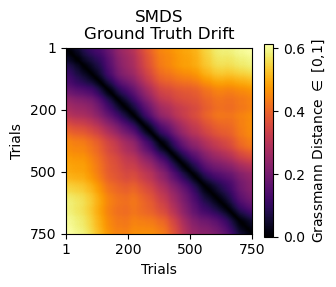

In [5]:
true_emissions_weights = true_params.emissions.weights
subspace_angle_matrix = compute_subspace_angle_matrix(true_emissions_weights)
normalized_grassmann_dist_matrix = jnp.linalg.norm(subspace_angle_matrix, ord=2, axis=-1) / (jnp.sqrt(D) * jnp.pi / 2)

plt.figure(figsize=(3,2.5))
plt.imshow(normalized_grassmann_dist_matrix, interpolation='None', vmin=0.0, cmap='inferno')
plt.colorbar(label=r'Grassmann Distance $\in$ [0,1]')
plt.title(f'SMDS\nGround Truth Drift')
plt.xticks([0, 250, 500, 749], [1, 200, 500, 750])
plt.yticks([0, 250, 500, 749], [1, 200, 500, 750])
plt.ylabel('Trials')
plt.xlabel('Trials')
plt.show()

In [6]:
true_smds_rotation, explained_variances = compute_rotation(emissions, true_emissions_weights)
rotated_true_emissions_weights = jnp.einsum('rij,jk->rik', true_emissions_weights, true_smds_rotation)
true_evs = vmap(compute_explained_variance, in_axes=(None, None, -1))(emissions, rotated_true_emissions_weights, rotated_true_emissions_weights[:, :, None])
original_true_evs = vmap(compute_explained_variance, in_axes=(None, None, -1))(emissions, true_emissions_weights, 
                                                                               true_emissions_weights[:, :, None])

In [7]:
true_cos_sims = np.zeros((D, num_trials))
true_cos_dists = np.zeros((D, num_trials))

rotated_true_cos_sims = np.zeros((D, num_trials))
rotated_true_cos_dists = np.zeros((D, num_trials))
for d in tqdm(range(D)):
    true_cos_sims[d] = vmap(compute_cos_sim, in_axes=(0, None))(true_emissions_weights[:,:,d], 
                                                                  true_emissions_weights[0,:,d])
    true_cos_dists[d] = vmap(compute_cos_dist, in_axes=(0, None))(true_emissions_weights[:,:,d], 
                                                                    true_emissions_weights[0,:,d])
    rotated_true_cos_sims[d] = vmap(compute_cos_sim, in_axes=(0, None))(rotated_true_emissions_weights[:,:,d], 
                                                                          rotated_true_emissions_weights[0,:,d])
    rotated_true_cos_dists[d] = vmap(compute_cos_dist, in_axes=(0, None))(rotated_true_emissions_weights[:,:,d], 
                                                                          rotated_true_emissions_weights[0,:,d])

100%|██████████| 2/2 [00:00<00:00, 12.75it/s]


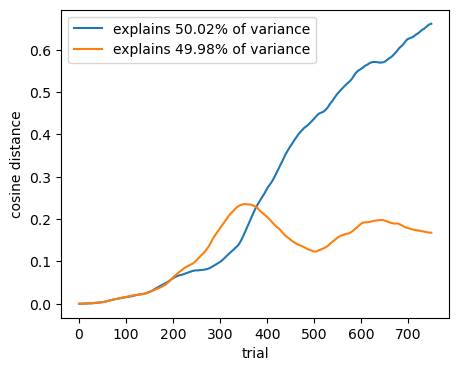

In [8]:
plt.figure(figsize=(5,4))
for d in range(D):
    plt.plot(rotated_true_cos_dists[d], label=f'explains {100*true_evs[d, 0]:.2f}% of variance')
plt.ylabel('cosine distance')
plt.xlabel('trial')
plt.legend()
plt.show()

# Fit LDS and SMDS on Training Data and Evaluate on Test Data

In [9]:
block_size = 1
num_blocks = len(emissions) // block_size
num_trials = num_blocks * block_size
emissions = emissions[:num_trials]
conditions = conditions[:num_trials]

block_masks = jnp.ones(num_blocks, dtype=bool)
trial_masks = jnp.ones(len(emissions), dtype=bool)
num_test_blocks = num_blocks // 6
key = jr.PRNGKey(2626)

test_idx = jax.random.choice(key, jnp.arange(30, num_blocks-30, dtype=int), shape=(num_test_blocks,), replace=False)

block_masks = block_masks.at[test_idx].set(False)
num_train_blocks = block_masks.sum()
block_ids = jnp.repeat(jnp.eye(num_blocks), block_size, axis=1)

trial_masks = jnp.repeat(block_masks, block_size)

train_obs = emissions
_, sequence_length, emission_dim = train_obs.shape
test_obs = train_obs[~trial_masks]

train_conditions = conditions[trial_masks]
test_conditions = conditions[~trial_masks]

In [10]:
xy_ekf_marginal_ll = true_model.marginal_log_prob(true_params, train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                  conditions=conditions.reshape(num_blocks, block_size), block_masks=jnp.ones(num_blocks, dtype=bool),
                                                  trial_masks=jnp.ones((num_blocks, block_size), dtype=bool), num_iters=1)
y_ekf_marginal_ll = true_model.marginal_log_prob(true_params, train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                 conditions=conditions.reshape(num_blocks, block_size), block_masks=block_masks, 
                                                 trial_masks=trial_masks.reshape(num_blocks, block_size), num_iters=1)
true_ekf_marginal_ll = xy_ekf_marginal_ll - y_ekf_marginal_ll
print('true_ekf_marginal_ll: ', true_ekf_marginal_ll)

true_ekf_marginal_ll:  29076.54063868127


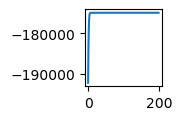

LDS D=1: test_marginal_ll=-33522.174631181086


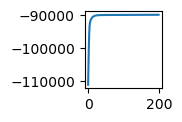

LDS D=2: test_marginal_ll=-16473.446296030128


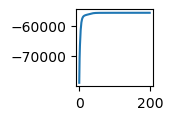

LDS D=3: test_marginal_ll=-9519.74802510273


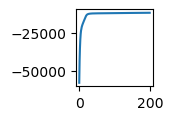

LDS D=4: test_marginal_ll=-533.581656901489


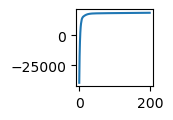

LDS D=5: test_marginal_ll=5236.16434689834


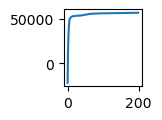

LDS D=6: test_marginal_ll=12936.134830527693


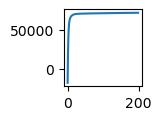

LDS D=7: test_marginal_ll=15440.496195210131


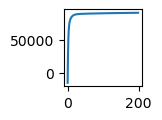

LDS D=8: test_marginal_ll=19252.713910300467


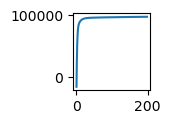

LDS D=9: test_marginal_ll=20205.04100253847


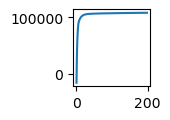

LDS D=10: test_marginal_ll=22162.172893519975


In [11]:
key = jr.PRNGKey(123456)

stationary_test_state_dims = np.arange(1, 11, 1)
num_iters = 200
test_marginal_lls = []
for test_state_dim in stationary_test_state_dims:
    test_model = LinearGaussianConjugateSSM(test_state_dim, emission_dim, 
                                            num_conditions=num_conditions,
                                            has_dynamics_bias=False, has_emissions_bias=False)
            
    key, this_key = jr.split(key, 2)

    base_subspace = PCA(n_components=emission_dim).fit(train_obs[trial_masks].reshape(-1, emission_dim)).components_.T
    emission_weights = base_subspace[:, :test_state_dim]
    
    test_params, param_props = test_model.initialize(key=this_key, 
                                                     emission_weights=emission_weights
                                                    )
    
    test_params, marginal_lls = test_model.fit_em(test_params, 
                                                  param_props, 
                                                  train_obs[trial_masks],
                                                  conditions=train_conditions,
                                                  num_iters=num_iters)
    
    plt.figure(figsize=(1,1))
    plt.plot(marginal_lls[1:])
    plt.show()

    test_marginal_ll = test_model.batch_marginal_log_prob(test_params, test_obs, conditions=test_conditions)
    
    test_marginal_lls.append(test_marginal_ll)
    print(f'LDS D={test_state_dim}: test_marginal_ll={test_marginal_ll}')

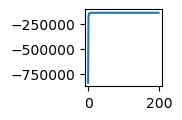

Elapsed time: 1.426861 seconds
SMDS D=1: test_marginal_ll=-33108.81830713092


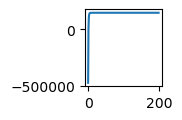

Elapsed time: 1.434174 seconds
SMDS D=2: test_marginal_ll=29015.90220455159


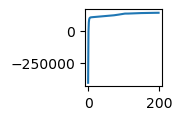

Elapsed time: 1.610558 seconds
SMDS D=3: test_marginal_ll=28570.55051264193


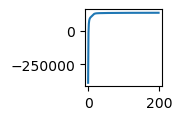

Elapsed time: 1.624526 seconds
SMDS D=4: test_marginal_ll=27123.650201079057


In [12]:
key = jr.PRNGKey(123456)
smds_test_state_dims = np.arange(1, 5, 1)
test_ekf_marginal_lls = []
num_iters = 200
for smds_test_state_dim in smds_test_state_dims:
    ddof = smds_test_state_dim * (emission_dim - smds_test_state_dim)
    dof = (smds_test_state_dim, emission_dim - smds_test_state_dim)
    test_model = StiefelManifoldSSM(smds_test_state_dim, 
                                    emission_dim,
                                    num_trials=len(train_obs),
                                    num_conditions=num_conditions,
                                    has_dynamics_bias=False,
                                    tau_per_dim=True,
                                    tau_per_axis=False,
                                    emissions_cov_eps=1e-9,
                                    max_tau=1e-3,
                                    ekf_num_iters=1,
                                    initial_velocity_covariance_prior=IG(concentration=1e-6, scale=1e-6),
                                    tau_prior=IG(concentration=1e-6, scale=1e-6),
                                    )

    U_base = PCA(n_components=emission_dim).fit(train_obs[trial_masks].reshape(-1, emission_dim)).components_.T
    emission_weights = jnp.tile(U_base[:, :smds_test_state_dim][None], (len(train_obs), 1, 1))
    
    key, key_root = jr.split(key)
    test_params, param_props, _ = test_model.initialize(U_base=U_base,
                                                        tau=jnp.ones(ddof)*1e-6,
                                                        emission_weights=emission_weights,
                                                        initial_velocity_cov=1e-4*jnp.eye(ddof),
                                                        key=key)
    
    test_params, marginal_lls = test_model.fit_em(test_params, param_props, 
                                                  train_obs,
                                                  conditions=conditions,
                                                  trial_masks=trial_masks,
                                                  block_ids=block_ids,
                                                  block_masks=block_masks,
                                                  num_iters=num_iters)

    plt.figure(figsize=(1,1))
    plt.plot(marginal_lls)
    plt.show()

    start_time = time.time()
    xy_ekf_marginal_ll = test_model.marginal_log_prob(test_params, train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                      conditions=conditions.reshape(num_blocks, block_size), block_masks=jnp.ones(num_blocks, dtype=bool),
                                                      trial_masks=jnp.ones((num_blocks, block_size), dtype=bool), num_iters=1)
    y_ekf_marginal_ll = test_model.marginal_log_prob(test_params, train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                     conditions=conditions.reshape(num_blocks, block_size), block_masks=block_masks, 
                                                     trial_masks=trial_masks.reshape(num_blocks, block_size), num_iters=1)
    test_ekf_marginal_ll = xy_ekf_marginal_ll - y_ekf_marginal_ll

    end_time = time.time()  # Record the end time
    
    elapsed_time = end_time - start_time  # Calculate the elapsed time in seconds
    print(f"Elapsed time: {elapsed_time:.6f} seconds")  # Print with microsecond precision    
    test_ekf_marginal_lls.append(test_ekf_marginal_ll)

    print(f'SMDS D={smds_test_state_dim}: test_marginal_ll={test_ekf_marginal_ll}')

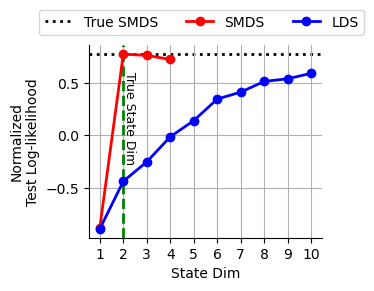

In [13]:
test_marginal_lls = np.array(test_marginal_lls)
test_ekf_marginal_lls = np.array(test_ekf_marginal_lls)
num_test_samples = (num_trials // 6) * N * num_timesteps

fig, ax = plt.subplots(figsize=(3,2.5))
plt.grid(True, zorder=0)

ax.axhline(true_ekf_marginal_ll / num_test_samples, color='k', linestyle=':', label='True SMDS', zorder=0, linewidth=2)

ax.plot(smds_test_state_dims, test_ekf_marginal_lls / num_test_samples, marker='o', color='r', label='SMDS', zorder=3, linewidth=2)

ax.plot(stationary_test_state_dims, test_marginal_lls / num_test_samples, marker='o', color='b', label='LDS', zorder=3, linewidth=2)


ax.axvline(2, color='g', linestyle='--', zorder=2, linewidth=2)
ax.text(2, -0.25, 'True State Dim', rotation=-90, fontsize=9)
ax.set_xlabel('State Dim')
ax.set_ylabel('Normalized\nTest Log-likelihood')
ax.set_xticks(stationary_test_state_dims)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 1.05), fontsize=10)

plt.show()

# Fit LDS D=3 and SMDS D=2 to all Data

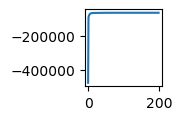

In [14]:
key = jr.PRNGKey(123456)
num_iters = 200
lds_models = []
for test_state_dim in [3]:
    test_model = LinearGaussianConjugateSSM(test_state_dim, emission_dim, 
                                            num_conditions=num_conditions,
                                            has_dynamics_bias=False, has_emissions_bias=False)
            
    key, this_key = jr.split(key, 2)

    base_subspace = PCA(n_components=emission_dim).fit(train_obs.reshape(-1, emission_dim)).components_.T
    emission_weights = base_subspace[:, :test_state_dim]
    
    test_params, param_props = test_model.initialize(key=this_key, 
                                                     emission_weights=emission_weights
                                                    )
    
    test_params, marginal_lls = test_model.fit_em(test_params, 
                                                  param_props, 
                                                  train_obs,
                                                  conditions=conditions,
                                                  num_iters=num_iters)
    
    plt.figure(figsize=(1,1))
    plt.plot(marginal_lls)
    plt.show()

    lds_models.append((test_model, test_params))

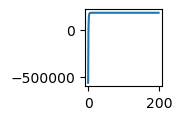

In [16]:
# run this
key = jr.PRNGKey(123456)
smds_models = []
num_iters = 200
for smds_test_state_dim in [2]:
    ddof = smds_test_state_dim * (emission_dim - smds_test_state_dim)
    dof = (smds_test_state_dim, emission_dim - smds_test_state_dim)
    test_model = StiefelManifoldSSM(smds_test_state_dim, 
                                    emission_dim,
                                    num_trials=len(train_obs),
                                    num_conditions=num_conditions,
                                    has_dynamics_bias=False,
                                    tau_per_dim=True,
                                    tau_per_axis=False,
                                    emissions_cov_eps=1e-9,
                                    max_tau=1e-3,
                                    ekf_num_iters=1,
                                    initial_velocity_covariance_prior=IG(concentration=1e-6, scale=1e-6),
                                    tau_prior=IG(concentration=1e-6, scale=1e-6),
                                    )

    U_base = PCA(n_components=emission_dim).fit(train_obs.reshape(-1, emission_dim)).components_.T
    emission_weights = jnp.tile(U_base[:, :smds_test_state_dim][None], (len(train_obs), 1, 1))
    
    key, key_root = jr.split(key)
    test_params, param_props, _ = test_model.initialize(U_base=U_base,
                                                        tau=jnp.ones(ddof)*1e-6,
                                                        emission_weights=emission_weights,
                                                        initial_velocity_cov=1e-4*jnp.eye(ddof),
                                                        key=key)
    
    test_params, marginal_lls = test_model.fit_em(test_params, param_props, 
                                                  train_obs,
                                                  conditions=conditions,
                                                  num_iters=num_iters)

    plt.figure(figsize=(1,1))
    plt.plot(marginal_lls)
    plt.show()
    
    smds_models.append((test_model, test_params))

# Plot True and Learned Dynamics

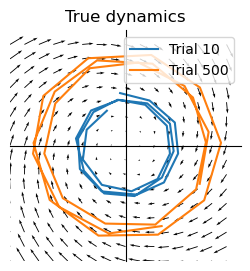

In [17]:
trial_idx = np.array([10, 500])

A = true_params.dynamics.weights
def vf_x(x, y):
    point = jnp.array([x, y])
    return A[0] @ point - x

def vf_y(x, y):
    point = jnp.array([x, y])
    return A[1] @ point - y

x_lim = (-6, 6)
y_lim = (-6, 6)

step = 0.75
scale = 6

X, Y = np.meshgrid(np.arange(x_lim[0], x_lim[1], step), np.arange(y_lim[0], y_lim[1], step))
U = np.zeros(X.shape)
V = np.zeros(Y.shape)

for i in range(X.shape[0]):
    for j in range(Y.shape[0]):
          U[i,j] = vf_x(X[i, j], Y[i, j])
          V[i,j] = vf_y(X[i, j], Y[i, j])
          
fig, ax = plt.subplots(figsize=(3, 3))
_ = ax.quiver(X, Y, U, V, units='xy', scale=scale, color='k')

plt.xlim(x_lim)
plt.ylim(y_lim)

ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

# Move axis to the middle
ax.spines['left'].set_position('zero')

ax.spines['right'].set_color('none')
ax.yaxis.tick_left()

ax.spines['bottom'].set_position('zero')

ax.spines['top'].set_color('none')
ax.xaxis.tick_bottom()
plt.grid()

for idx in trial_idx:
    ax.plot(*true_states[idx].T, label=f'Trial {idx}')
plt.title('True dynamics')
plt.legend()
plt.show()

In [21]:
velocity_smoother1 = smds_models[0][0].smoother(smds_models[0][1], train_obs.reshape(num_blocks, block_size, sequence_length, emission_dim), 
                                                conditions.reshape(num_blocks, block_size), 
                                                jnp.ones(num_blocks, dtype=bool), num_iters=1)
Ev1 = velocity_smoother1.smoothed_means

Hs1 = vmap(rotate_subspace, in_axes=(None, None, 0))(smds_models[0][1].emissions.U_base, D, Ev1)

mu_0 = smds_models[0][1].initial.mean
Sigma_0 = smds_models[0][1].initial.cov
A = smds_models[0][1].dynamics.weights
b = smds_models[0][1].dynamics.bias
Q = smds_models[0][1].dynamics.cov
R = smds_models[0][1].emissions.cov

def batch_smoothed_xs(H, ys, condition):
    trial_test_params = make_lgssm_params(mu_0,
                                          Sigma_0,
                                          A,
                                          Q,
                                          H,
                                          R,
                                          dynamics_bias=b)

    posterior = lgssm_smoother(trial_test_params, ys, condition)
    return posterior.smoothed_means

smds_smoothed_xs = vmap(batch_smoothed_xs)(Hs1,
                                           train_obs,
                                           conditions)

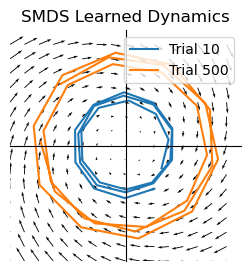

In [22]:
A = smds_models[0][1].dynamics.weights
def vf_x(x, y):
    point = jnp.array([x, y])
    return A[0] @ point - x

def vf_y(x, y):
    point = jnp.array([x, y])
    return A[1] @ point - y

x_lim = (-6, 6)
y_lim = (-6, 6)

step = 0.75
scale = 6

X, Y = np.meshgrid(np.arange(x_lim[0], x_lim[1], step), np.arange(y_lim[0], y_lim[1], step))
U = np.zeros(X.shape)
V = np.zeros(Y.shape)

for i in range(X.shape[0]):
    for j in range(Y.shape[0]):
          U[i,j] = vf_x(X[i, j], Y[i, j])
          V[i,j] = vf_y(X[i, j], Y[i, j])
          
fig, ax = plt.subplots(figsize=(3, 3))
_ = ax.quiver(X, Y, U, V, units='xy', scale=scale, color='k')

plt.xlim(x_lim)
plt.ylim(y_lim)

ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect('equal')

# Move axis to the middle
ax.spines['left'].set_position('zero')

ax.spines['right'].set_color('none')
ax.yaxis.tick_left()

ax.spines['bottom'].set_position('zero')

ax.spines['top'].set_color('none')
ax.xaxis.tick_bottom()
plt.grid()

for idx in trial_idx:
    ax.plot(*smds_smoothed_xs[idx].T, label=f'Trial {idx}')
plt.title('SMDS Learned Dynamics')
plt.legend()
plt.show()

In [23]:
lds_smoothed_xs_3D = lds_models[0][0].batch_smoother(lds_models[0][1], train_obs, 
                                           conditions=conditions).smoothed_means

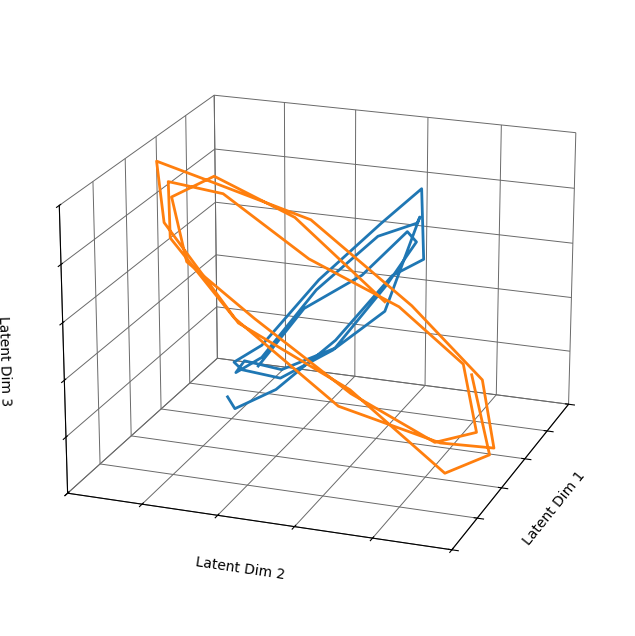

In [24]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import LinearLocator

fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')

for idx in trial_idx:
    ax.plot(*lds_smoothed_xs_3D[idx].T, label=f'Trial {idx}', linewidth=2)

pane_color_rgba = (1.0, 1.0, 1.0, 1.0)
ax.xaxis.set_pane_color(pane_color_rgba)
ax.yaxis.set_pane_color(pane_color_rgba)
ax.zaxis.set_pane_color(pane_color_rgba)

pane_edge_color = 'white'
pane_edge_linewidth = 1.5
ax.xaxis.pane.set_edgecolor(pane_edge_color)
ax.yaxis.pane.set_edgecolor(pane_edge_color)
ax.zaxis.pane.set_edgecolor(pane_edge_color)
ax.xaxis.pane.set_linewidth(pane_edge_linewidth)
ax.yaxis.pane.set_linewidth(pane_edge_linewidth)
ax.zaxis.pane.set_linewidth(pane_edge_linewidth)

num_grid_lines = 6
ax.xaxis.set_major_locator(LinearLocator(numticks=num_grid_lines))
ax.yaxis.set_major_locator(LinearLocator(numticks=num_grid_lines))
ax.zaxis.set_major_locator(LinearLocator(numticks=num_grid_lines))

grid_line_color = 'dimgray'
grid_line_width = 0.7

for axis_obj in [ax.xaxis, ax.yaxis, ax.zaxis]:
    axis_obj._axinfo["grid"].update({
        'color': grid_line_color,
        'linewidth': grid_line_width,
        'linestyle': '-'
    })

# Remove tick labels
ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_zticklabels([])

ax.set_xlabel('Latent Dim 1')
ax.set_ylabel('Latent Dim 2')
ax.set_zlabel('Latent Dim 3')

# Make tick marks invisible (zero length)
ax.tick_params(axis='x', length=0)
ax.tick_params(axis='y', length=0)
ax.tick_params(axis='z', length=0)

ax.view_init(elev=20, azim=20)
plt.show()

# Plot True Drift and Drift Learned by an SMDS

In [25]:
subspace_angle_matrix = compute_subspace_angle_matrix(Hs1)
inferred_normalized_grassmann_dist_matrix = jnp.linalg.norm(subspace_angle_matrix, ord=2, axis=-1) / (jnp.sqrt(D) * jnp.pi / 2)

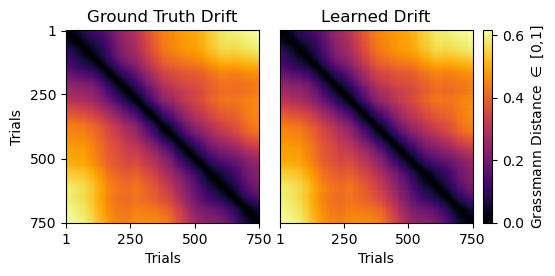

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(5.5,2.5), gridspec_kw={'width_ratios': [1, 1.1], 'wspace': 0.1})

vmin = jnp.concatenate([normalized_grassmann_dist_matrix, inferred_normalized_grassmann_dist_matrix]).min()
vmax = jnp.concatenate([normalized_grassmann_dist_matrix, inferred_normalized_grassmann_dist_matrix]).max()

axs[0].imshow(normalized_grassmann_dist_matrix, aspect='auto', interpolation='none', vmin=vmin, vmax=vmax, cmap='inferno')
axs[0].set_ylabel('Trials')
axs[0].set_xlabel('Trials')
axs[0].set_yticks([1, 250, 500, 750])
axs[0].set_xticks([1, 250, 500, 750])
axs[0].set_title('Ground Truth Drift')

im = axs[1].imshow(inferred_normalized_grassmann_dist_matrix, aspect='auto', interpolation='none', vmin=vmin, vmax=vmax, cmap='inferno')
axs[1].set_yticks([])
axs[1].set_xticks([1, 250, 500, 750])
axs[1].set_xlabel('Trials')
axs[1].set_title('Learned Drift')
divider = make_axes_locatable(axs[1])
cax = divider.append_axes("right", size="5%", pad=0.1)
cbar = fig.colorbar(im, cax=cax)
cbar.ax.set_ylabel(r'Grassmann Distance $\in$ [0,1]')

plt.show()

In [27]:
smds_rotation, explained_variances = compute_rotation(emissions, Hs1)
rotated_inferred_emissions_weights = jnp.einsum('rij,jk->rik', Hs1, smds_rotation)
inferred_evs = vmap(compute_explained_variance, in_axes=(None, None, -1))(emissions, rotated_inferred_emissions_weights, 
                                                                          rotated_inferred_emissions_weights[:, :, None])

A = smds_models[0][1].dynamics.weights
smds_rotation_inv = jnp.linalg.inv(smds_rotation)
transformed_smds_A = smds_rotation @ A @ smds_rotation_inv

In [28]:
rotated_inferred_cos_sims_diag = np.zeros((D, num_trials-1))
rotated_inferred_cos_dists_diag = np.zeros((D, num_trials-1))
for d in tqdm(range(D)):
    rotated_inferred_cos_sims_diag[d] = vmap(compute_cos_sim, in_axes=(0, 0))(rotated_inferred_emissions_weights[1:,:,d], 
                                                                          rotated_inferred_emissions_weights[:-1,:,d])
    rotated_inferred_cos_dists_diag[d] = vmap(compute_cos_dist, in_axes=(0, 0))(rotated_inferred_emissions_weights[1:,:,d], 
                                                                          rotated_inferred_emissions_weights[:-1,:,d])

inferred_diag_thetas = np.rad2deg(jnp.arccos(jnp.clip(rotated_inferred_cos_sims_diag, min=-1, max=1)))
inferred_diag_thetas = np.array(inferred_diag_thetas)

rotated_inferred_cos_sims = np.zeros((D, num_trials))
rotated_inferred_cos_dists = np.zeros((D, num_trials))
for d in tqdm(range(D)):
    rotated_inferred_cos_sims[d] = vmap(compute_cos_sim, in_axes=(0, None))(rotated_inferred_emissions_weights[:,:,d], 
                                                                          rotated_inferred_emissions_weights[0,:,d])
    rotated_inferred_cos_dists[d] = vmap(compute_cos_dist, in_axes=(0, None))(rotated_inferred_emissions_weights[:,:,d], 
                                                                          rotated_inferred_emissions_weights[0,:,d])

100%|██████████| 2/2 [00:00<00:00, 324.05it/s]


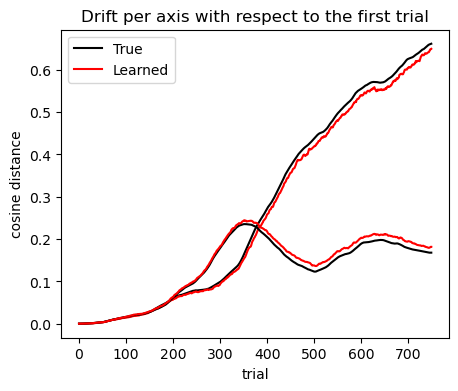

In [29]:
plt.figure(figsize=(5,4))
for d in range(D):
    if d == 0:
        plt.plot(rotated_true_cos_dists[d], label='True', color='k')
        plt.plot(rotated_inferred_cos_dists[d], label='Learned', color='r')
    else:
        plt.plot(rotated_true_cos_dists[d], color='k')
        plt.plot(rotated_inferred_cos_dists[d], color='r')
plt.ylabel('cosine distance')
plt.xlabel('trial')
plt.title('Drift per axis with respect to the first trial')
plt.legend()
plt.show()